# Exploración inicial — AlertaSegura Perú uwu

Sprint 1 · Data Analysis

Carga el dataset sintético (`data/reportes_sinteticos.csv`) generado con
`scripts/generar_dataset.py` y hace una primera exploración: estructura,
nulos, y las métricas definidas en `fields_and_metrics.md`
(reportes por distrito, por categoría, por hora, tasa de verificación).

In [12]:
#holi
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

reportes = pd.read_csv("../data/reportes_sinteticos.csv", parse_dates=["created_at"])
usuarios = pd.read_csv("../data/usuarios.csv", parse_dates=["created_at"])
categorias = pd.read_csv("../data/categorias.csv")

reportes.head()

,id,usuario_id,categoria,descripcion,latitud,longitud,distrito,estado,created_at
0,1,22,Bache,Pista deteriorada genera accidentes,-12.222394,-76.928030,Villa El Salvador,PENDIENTE,2026-05-14 01:06:00
1,2,39,Bache,Hueco profundo sin señalizar,-11.977605,-77.084275,San Martín de Porres,VERIFICADO,2026-06-18 01:18:00
2,3,24,Acoso,Un sujeto acosó a una mujer en la vereda,-11.964809,-77.079884,Los Olivos,VERIFICADO,2026-05-30 20:05:00
3,4,25,Bache,Hueco profundo sin señalizar,-12.043686,-77.045503,Cercado de Lima,PENDIENTE,2026-06-17 05:42:00
4,5,5,Acoso,Acoso a estudiantes cerca del colegio,-12.157617,-76.974004,San Juan de Miraflores,VERIFICADO,2026-06-29 06:59:00


## 1. Estructura y calidad de los datos

In [13]:
reportes.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           120 non-null    int64         
 1   usuario_id   120 non-null    int64         
 2   categoria    120 non-null    str           
 3   descripcion  120 non-null    str           
 4   latitud      120 non-null    float64       
 5   longitud     120 non-null    float64       
 6   distrito     120 non-null    str           
 7   estado       120 non-null    str           
 8   created_at   120 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(2), int64(2), str(4)
memory usage: 8.6 KB


In [14]:
reportes.isnull().sum()

id             0
usuario_id     0
categoria      0
descripcion    0
latitud        0
longitud       0
distrito       0
estado         0
created_at     0
dtype: int64

In [15]:
reportes.duplicated().sum()

np.int64(0)

## 2. Reportes por distrito

In [16]:
conteo_distrito = reportes["distrito"].value_counts()
conteo_distrito

distrito
Callao                     14
Puente Piedra              13
Miraflores                 10
Villa El Salvador           9
Ate                         9
Los Olivos                  8
Rímac                       8
Chorrillos                  8
La Victoria                 6
Comas                       6
San Juan de Lurigancho      6
Cercado de Lima             5
San Juan de Miraflores      5
Independencia               5
Villa María del Triunfo     4
San Martín de Porres        3
San Isidro                  1
Name: count, dtype: int64

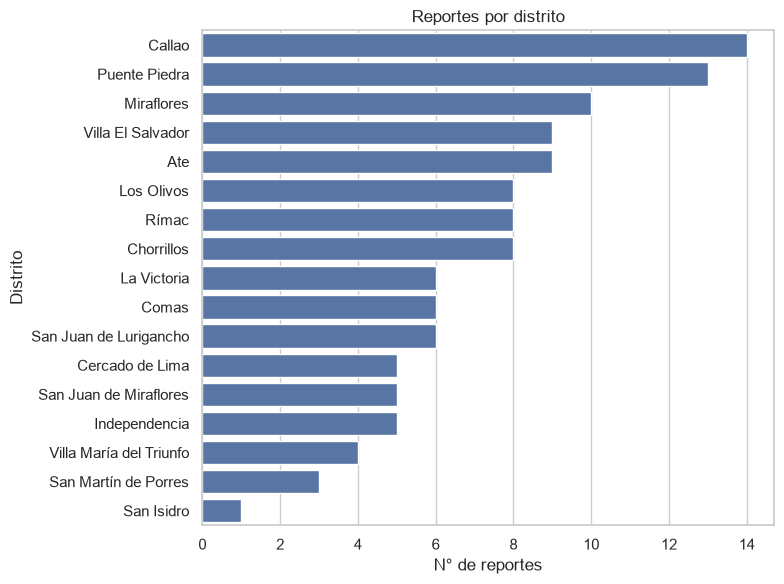

In [17]:
plt.figure(figsize=(8, 6))
sns.barplot(y=conteo_distrito.index, x=conteo_distrito.values)
plt.title("Reportes por distrito")
plt.xlabel("N° de reportes")
plt.ylabel("Distrito")
plt.tight_layout()
plt.show()

## 3. Reportes por categoría

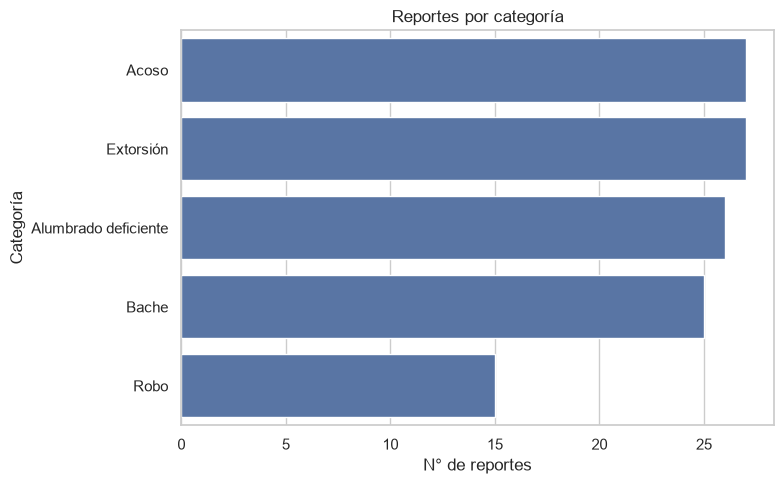

In [18]:
conteo_categoria = reportes["categoria"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(y=conteo_categoria.index, x=conteo_categoria.values)
plt.title("Reportes por categoría")
plt.xlabel("N° de reportes")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()

## 4. Reportes por hora del día

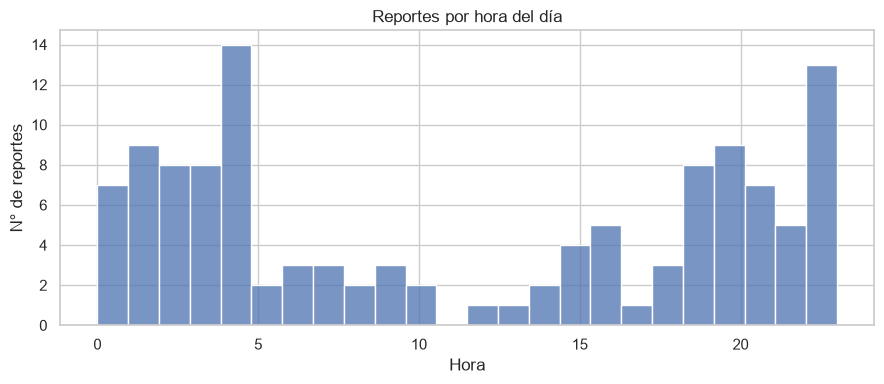

In [19]:
reportes["hora"] = reportes["created_at"].dt.hour
reportes["dia_semana"] = reportes["created_at"].dt.day_name()

plt.figure(figsize=(9, 4))
sns.histplot(reportes["hora"], bins=24)
plt.title("Reportes por hora del día")
plt.xlabel("Hora")
plt.ylabel("N° de reportes")
plt.tight_layout()
plt.show()

## 5. Tasa de verificación (`estado`)

In [20]:
reportes["estado"].value_counts(normalize=True) * 100

estado
PENDIENTE     45.833333
VERIFICADO    40.833333
RECHAZADO     13.333333
Name: proportion, dtype: float64

In [21]:
pd.crosstab(reportes["categoria"], reportes["estado"], normalize="index") * 100

estado,PENDIENTE,RECHAZADO,VERIFICADO
categoria,,,
Acoso,51.851852,3.703704,44.444444
Alumbrado deficiente,50.000000,15.384615,34.615385
Bache,44.000000,12.000000,44.000000
Extorsión,33.333333,22.222222,44.444444
Robo,53.333333,13.333333,33.333333


## 6. Mapa rápido de reportes (lat/lon)

In [22]:
import folium

mapa = folium.Map(location=[-12.0464, -77.0428], zoom_start=11)
for _, row in reportes.iterrows():
    folium.CircleMarker(
        location=[row["latitud"], row["longitud"]],
        radius=3,
        popup=f"{row['categoria']} — {row['distrito']}",
        color="crimson",
        fill=True,
    ).add_to(mapa)

mapa

## Próximos pasos (Sprint 2+)

- Reemplazar el CSV por datos reales de la API/BD cuando esté disponible.
- Script de limpieza formal (nulos, duplicados, formatos) — Sprint 2.
- Dataset más realista de 150-300 registros — Sprint 3.
- Modelo de zonas de riesgo (KMeans/heatmap) y dashboard — Sprint 4.